In [2]:
# ---------------------------------------------------------
# Cell 1: Import Libraries
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import ipywidgets as widgets
from IPython.display import display, clear_output
import urllib.request
import zipfile
import os
import warnings
warnings.filterwarnings('ignore') # Keeps our presentation clean from red warning text

print("Step 1 Complete: All libraries imported successfully!")

Step 1 Complete: All libraries imported successfully!


In [3]:
# ---------------------------------------------------------
# Cell 2: Download the MODERN MovieLens Dataset
# ---------------------------------------------------------
def fetch_modern_data():
    url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    zip_path = "ml-latest-small.zip"
    
    if not os.path.exists("ml-latest-small"):
        print("Downloading modern MovieLens dataset...")
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall()
        print("Download complete.")
    else:
        print("Modern dataset found locally.")

fetch_modern_data()

# The modern dataset is cleaner, but removed user demographics for privacy.
ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv('ml-latest-small/movies.csv')

# Merge them together
data = pd.merge(ratings, movies, on='movieId')
print(f"Step 2 Complete: Loaded {len(data)} modern movie ratings!")

Download complete.
Step 2 Complete: Loaded 100836 modern movie ratings!


In [4]:
# ---------------------------------------------------------
# Cell 3: Advanced Model Training (Better RMSE & Variety)
# ---------------------------------------------------------
print("Extracting advanced features and training the model...")

# 1. Calculate user and movie averages
user_avg = data.groupby('userId')['rating'].mean().reset_index().rename(columns={'rating': 'user_avg_rating'})
movie_avg = data.groupby('movieId')['rating'].mean().reset_index().rename(columns={'rating': 'movie_avg_rating'})

# NEW: Calculate Movie Popularity (How many ratings did it get?)
movie_popularity = data.groupby('movieId')['rating'].count().reset_index().rename(columns={'rating': 'rating_count'})

data = pd.merge(data, user_avg, on='userId')
data = pd.merge(data, movie_avg, on='movieId')
data = pd.merge(data, movie_popularity, on='movieId')

# NEW: Extract the Release Year from the movie title using a regular expression
data['release_year'] = data['title'].str.extract(r'\((\d{4})\)').astype(float)
# Fill any missing years with the median year to prevent errors
data['release_year'] = data['release_year'].fillna(data['release_year'].median())

# 2. Extract Genres 
genre_dummies = data['genres'].str.get_dummies(sep='|')
data = pd.concat([data, genre_dummies], axis=1)

all_genres = list(genre_dummies.columns)
if '(no genres listed)' in all_genres: all_genres.remove('(no genres listed)')

# 3. Define our upgraded features!
features = ['userId', 'movieId', 'user_avg_rating', 'movie_avg_rating', 'rating_count', 'release_year'] + all_genres

X = data[features]
y = data['rating']

# 4. Train the model (Slightly deeper trees for the new features)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=150, learning_rate=0.1, max_depth=6)
model.fit(X_train, y_train)

# 5. Prepare the Movie Catalog for the UI
catalog_cols = ['movieId', 'title', 'genres', 'movie_avg_rating', 'rating_count', 'release_year'] + all_genres
movie_catalog = data[catalog_cols].drop_duplicates()

rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
print(f"Step 3 Complete! Error margin (RMSE): {rmse:.2f} stars.")

Extracting advanced features and training the model...
Step 3 Complete! Error margin (RMSE): 0.78 stars.


In [5]:
# ---------------------------------------------------------
# Cell 4: Smart Match UI (Always shows 5, changes on click)
# ---------------------------------------------------------
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. UI Widgets ---
critic_slider = widgets.FloatSlider(
    value=3.0, min=1.0, max=5.0, step=0.1, 
    description='Critic Level:', 
    tooltip='1.0 = Loves everything, 5.0 = Hates everything'
)

checkboxes = [widgets.Checkbox(value=False, description=genre, indent=False) for genre in all_genres]
genre_grid = widgets.GridBox(
    checkboxes, 
    layout=widgets.Layout(grid_template_columns="repeat(4, 150px)")
)

predict_btn = widgets.Button(description="Show My Top Movies!", button_style='success')
output_area = widgets.Output()

# --- 2. Prediction Logic ---
def generate_modern_predictions(b):
    with output_area:
        clear_output()
        
        selected_genres = [cb.description for cb in checkboxes if cb.value]
        
        if not selected_genres:
            print("⚠️ Please check at least one genre!")
            return
            
        print(f"Analyzing {len(selected_genres)} selected genres for the best matches...\n")
        
        live_data = movie_catalog.copy()
        live_data['userId'] = 999999
        live_data['user_avg_rating'] = 6.0 - critic_slider.value
        
        # Predict ratings
        live_data['predicted_rating'] = model.predict(live_data[features])
        
        # NEW: The Smart Match System
        # 1. Count how many of the checked genres each movie actually has
        live_data['match_count'] = live_data[selected_genres].sum(axis=1)
        
        # 2. Filter out movies that have ZERO matches
        filtered_movies = live_data[live_data['match_count'] > 0]
        
        if len(filtered_movies) == 0:
            print("❌ No movies exist with those genres!")
            return
        
        # 3. Sort primarily by the Match Score, then by the AI's predicted rating
        top_pool = filtered_movies.sort_values(by=['match_count', 'predicted_rating'], ascending=[False, False]).head(20)
        
        # 4. Pick 5 randomly from the top 20 to keep it fresh, then re-sort them so the best are on top
        if len(top_pool) >= 5:
            final_5 = top_pool.sample(5).sort_values(by=['match_count', 'predicted_rating'], ascending=[False, False])
        else:
            final_5 = top_pool.sort_values(by=['match_count', 'predicted_rating'], ascending=[False, False])
        
        print(f"🍿 Your Smart Matches (Critic Level: {critic_slider.value}/5.0):")
        for index, row in final_5.iterrows():
            stars = round(row['predicted_rating'], 2)
            match_pct = int((row['match_count'] / len(selected_genres)) * 100)
            print(f"⭐️ {stars} / 5.0 [{match_pct}% Genre Match] --> {row['title']}")

# --- 3. Display ---
predict_btn.on_click(generate_modern_predictions)

ui_layout = widgets.VBox([
    widgets.HTML("<h2>🍿 Modern AI Movie Matchmaker</h2>"),
    widgets.HTML("<p>1. Set your strictness. The higher the rating the harsher a critic you are!</p>"),
    critic_slider,
    widgets.HTML("<p>2. Select exactly what you are in the mood for:</p>"),
    genre_grid,
    widgets.HTML("<br>"),
    predict_btn,
    widgets.HTML("<hr>"),
    output_area
])

display(ui_layout)

Matplotlib is building the font cache; this may take a moment.


Generating Analytics Dashboard... (This may take a few seconds for the Brain Scan)



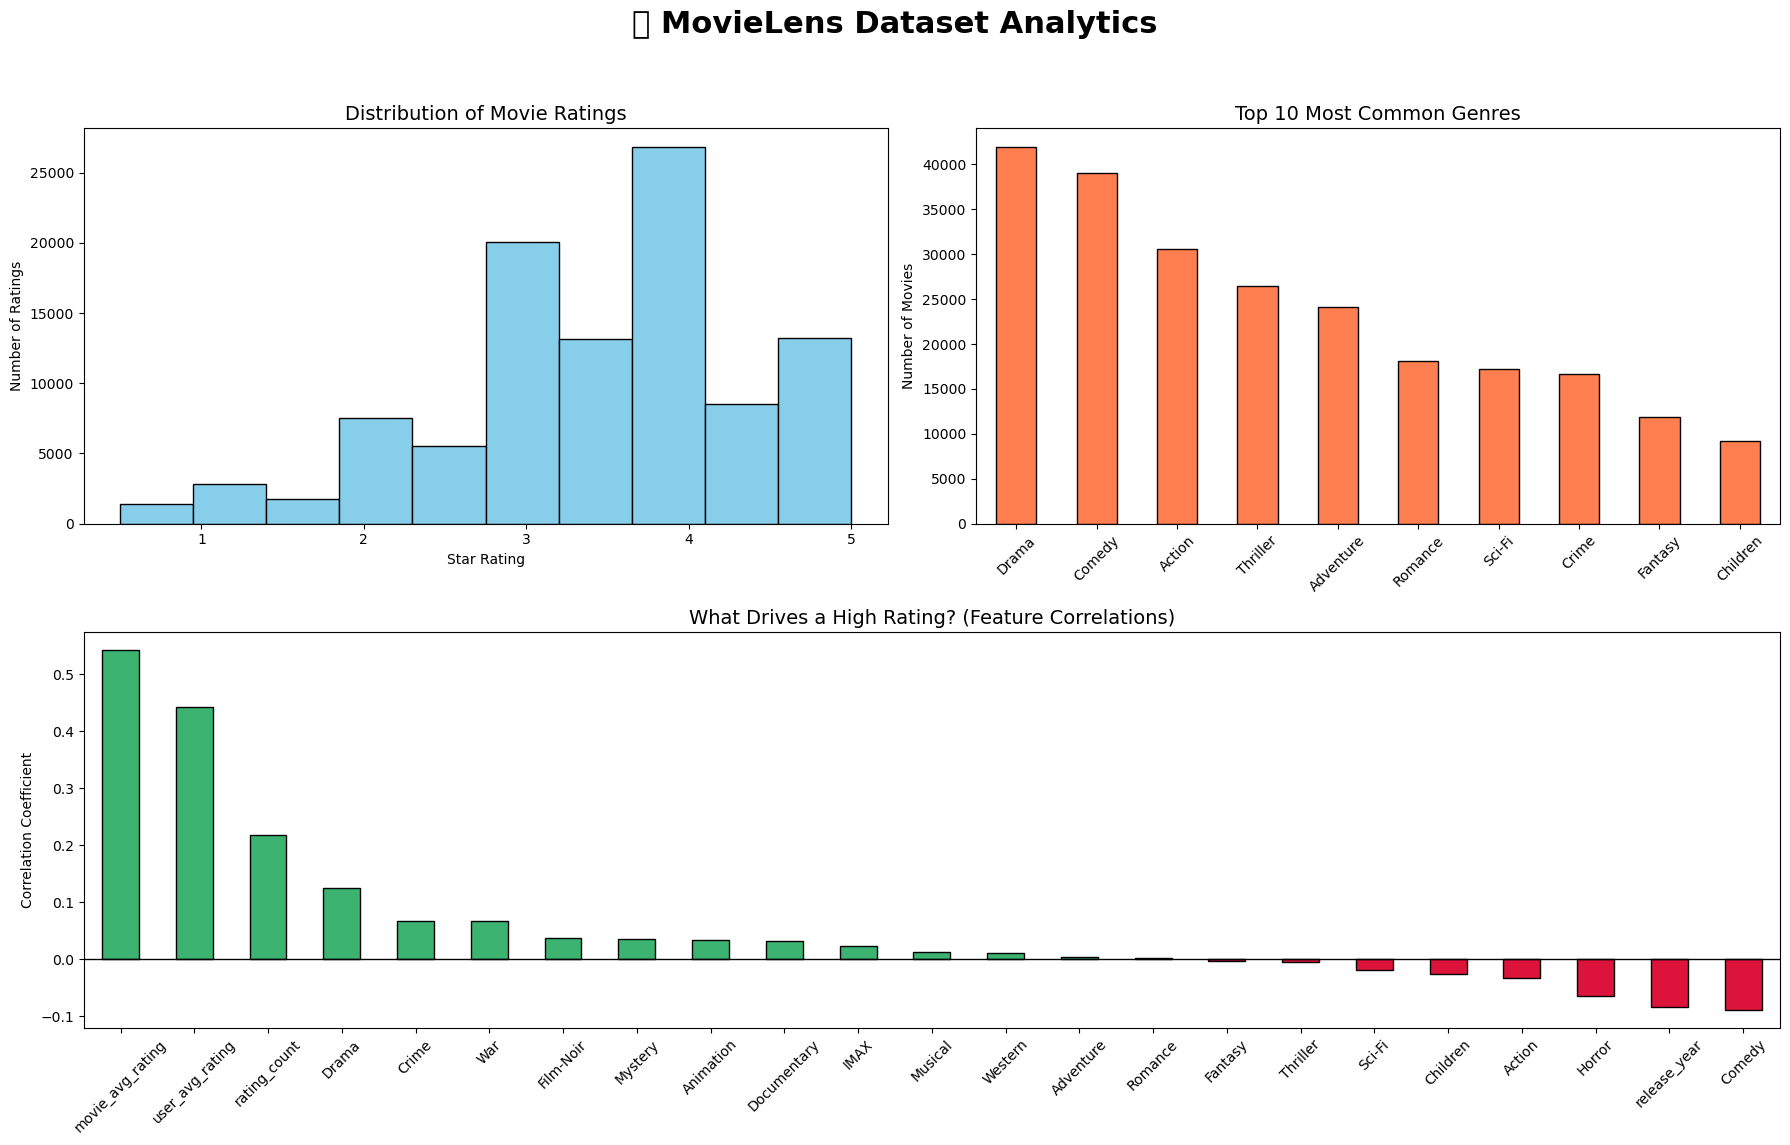


🧠 AI Brain Scan: Feature Importance (Powered by SHAP)



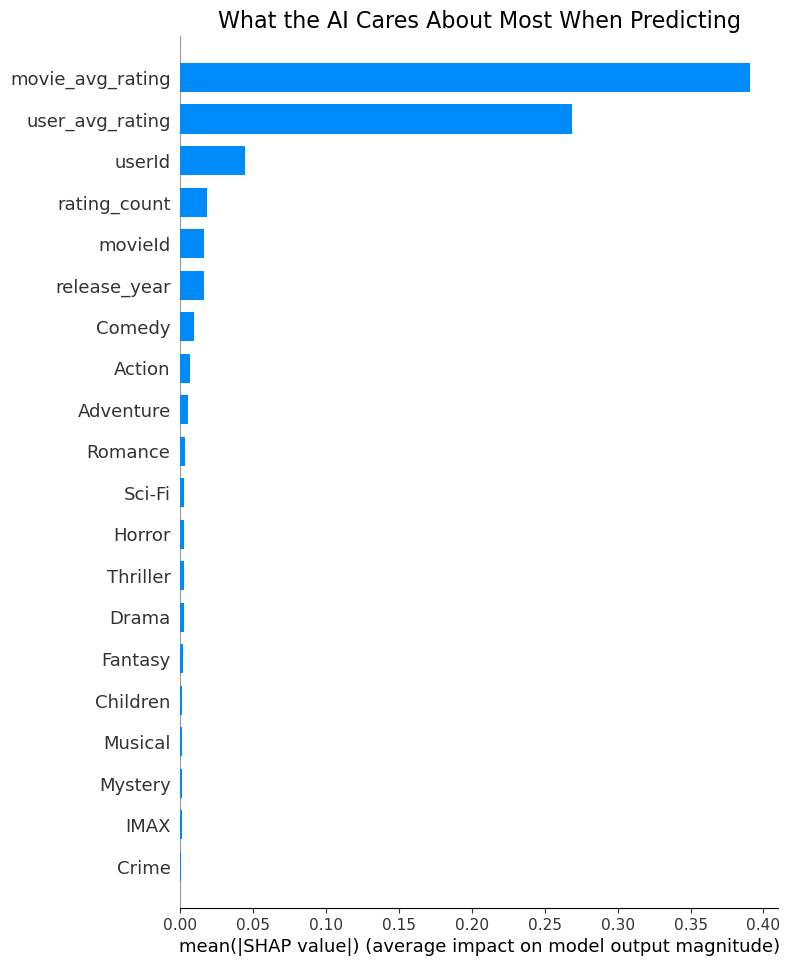

In [6]:
# ---------------------------------------------------------
# Cell 5: Comprehensive Analytics & AI Brain Scan (SHAP)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import shap
import numpy as np
import warnings

# Suppress warnings for a clean presentation
warnings.filterwarnings('ignore')

print("Generating Analytics Dashboard... (This may take a few seconds for the Brain Scan)\n")

# --- PART 1: DATASET ANALYTICS ---
# Set up a beautiful, large figure layout
fig = plt.figure(figsize=(18, 12))
plt.suptitle("🎬 MovieLens Dataset Analytics", fontsize=22, fontweight='bold')

# Chart A: Rating Distribution (Top Left)
ax1 = fig.add_subplot(2, 2, 1)
ax1.hist(data['rating'], bins=10, color='skyblue', edgecolor='black')
ax1.set_title("Distribution of Movie Ratings", fontsize=14)
ax1.set_xlabel("Star Rating")
ax1.set_ylabel("Number of Ratings")

# Chart B: Top 10 Most Popular Genres (Top Right)
ax2 = fig.add_subplot(2, 2, 2)
# Sum the 1s for each genre column to find the most common ones
genre_counts = data[all_genres].sum().sort_values(ascending=False).head(10)
genre_counts.plot(kind='bar', color='coral', ax=ax2, edgecolor='black')
ax2.set_title("Top 10 Most Common Genres", fontsize=14)
ax2.set_ylabel("Number of Movies")
ax2.tick_params(axis='x', rotation=45)

# Chart C: Correlation with Ratings (Bottom Spanning)
ax3 = fig.add_subplot(2, 1, 2)
# Calculate how each feature correlates specifically with the final rating
correlations = data[features + ['rating']].corr()['rating'].drop('rating').sort_values(ascending=False)
# Drop the ID columns since their numbers are meaningless
correlations = correlations.drop(['userId', 'movieId'], errors='ignore')

# Color it green for positive correlation, red for negative
colors = np.where(correlations > 0, 'mediumseagreen', 'crimson')
correlations.plot(kind='bar', color=colors, ax=ax3, edgecolor='black')
ax3.set_title("What Drives a High Rating? (Feature Correlations)", fontsize=14)
ax3.set_ylabel("Correlation Coefficient")
ax3.axhline(0, color='black', linewidth=1)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- PART 2: THE AI BRAIN SCAN (SHAP) ---
print("\n" + "="*60)
print("🧠 AI Brain Scan: Feature Importance (Powered by SHAP)")
print("="*60 + "\n")

# SHAP calculates the exact impact of every feature on the model's predictions.
# We sample 1,000 rows so it runs fast enough for a live presentation.
explainer = shap.TreeExplainer(model)
X_sample = X_train.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Generate a static SHAP summary bar plot (perfect for Voila)
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("What the AI Cares About Most When Predicting", fontsize=16)
plt.show()